# Student Information
**Name:** Faisal AL Zahrani  
**Student ID:** 2230000363  
**Lab:** Lab 4 — Classification and Evaluation in NLP

# Classification and Evaluation in NLP

**Text classification** is a common Natural Language Processing (NLP) task where a model assigns a predefined category or label to a piece of text.

Examples include:
- Spam detection
- Sentiment analysis
- News categorization

In this lab, we will learn how to build and evaluate a text classification model.

## Case Study: Sentiment Analysis

Sentiment analysis, also known as opinion mining, its goal is to understand the information present in the text and categorize it as positive, negative, or neutral.

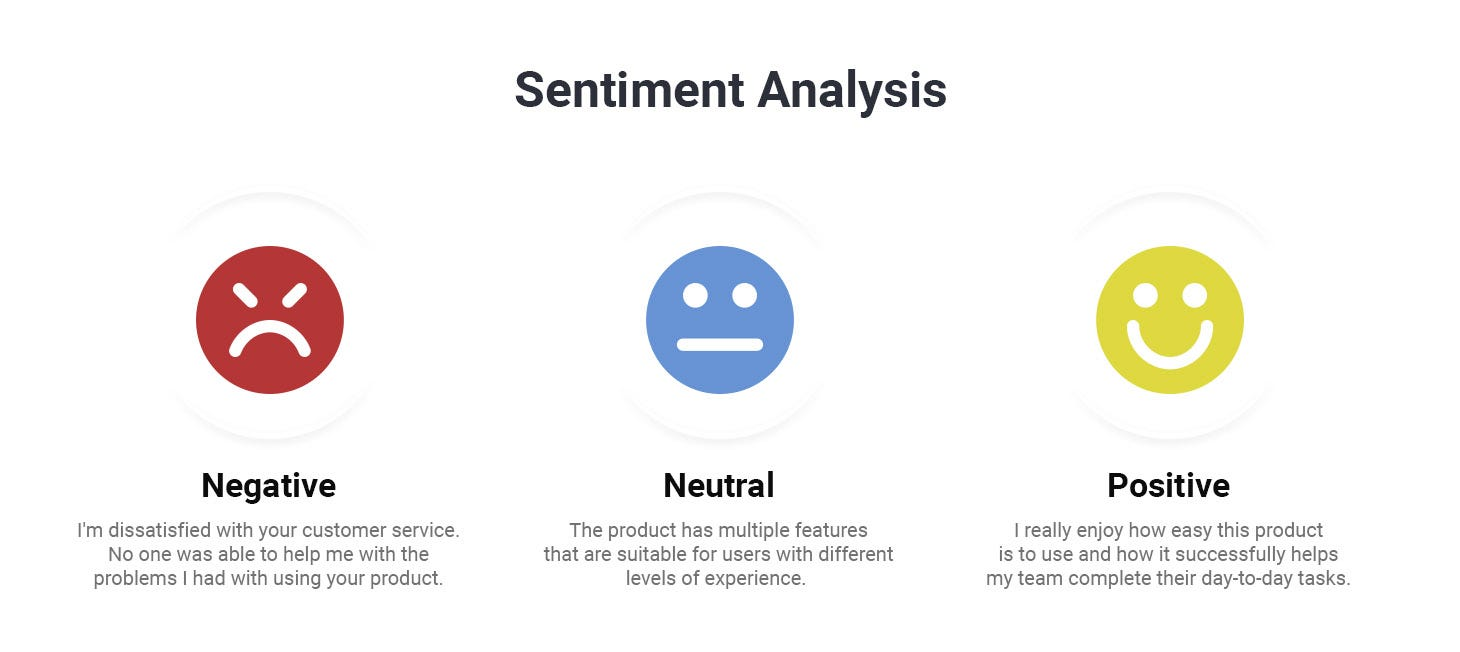

## Environment and Reproducibility
Run all cells in order using **Python 3.11 or later**. Saved outputs are included. The setup installs missing packages only. The datasets are read directly from the ZIP archives in `data/`; if an archive is missing, it is downloaded from the original Kaggle source. No NLTK resource download is needed.

All ratings are converted to three classes: **1–2 = negative**, **3 = neutral**, **4–5 = positive**. Both cases use an 80/20 stratified split with seed **42**, training-only TF-IDF fitting, and fixed model settings. Test results are used only for final evaluation.

In [1]:
import importlib.util
import importlib.metadata
import subprocess
import sys

packages = {
    "pandas": ("pandas", "pandas==2.3.3"),
    "numpy": ("numpy", "numpy>=1.26,<3"),
    "sklearn": ("scikit-learn", "scikit-learn==1.8.0"),
    "matplotlib": ("matplotlib", "matplotlib==3.10.7"),
}
missing = [requirement for module, (_, requirement) in packages.items()
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *missing])
print("Python:", sys.version.split()[0])
for distribution, _ in packages.values():
    print(f"{distribution}: {importlib.metadata.version(distribution)}")

import pandas as pd
import numpy as np
from IPython.display import display, Markdown
RANDOM_SEED = 42
LABELS = ["negative", "neutral", "positive"]
pd.set_option("display.max_colwidth", 100)

Python: 3.14.0
pandas: 2.3.3
numpy: 2.3.3
scikit-learn: 1.8.0
matplotlib: 3.10.7


### Dataset Loader
Use the exact files referenced in the lab. The loader verifies the CSV's SHA-256 fingerprint before reading it and never extracts or modifies the original data. Keep both ZIP files in `data/` for offline reruns once dependencies are installed.

In [2]:
from pathlib import Path
from urllib.request import Request, urlopen
import hashlib
import io
import zipfile

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
DATASETS = {
    "disneyland": {
        "ref": "arushchillar/disneyland-reviews",
        "archive": "disneyland_reviews_v1.zip",
        "csv": "DisneylandReviews.csv",
        "encoding": "latin-1",
        "sha256": "3c5eb28455a5156bbe337b3768fdd422a3311c1a91cb33214682bf80419e885c",
    },
    "amazon": {
        "ref": "PromptCloudHQ/amazon-reviews-unlocked-mobile-phones",
        "archive": "amazon_unlocked_phones_v1.zip",
        "csv": "Amazon_Unlocked_Mobile.csv",
        "encoding": "utf-8",
        "sha256": "097abeefe303816e0f5e9c9ff380adb25910cf46307d2c104911eae8d0304e76",
    },
}

def load_dataset(key):
    specification = DATASETS[key]
    archive_path = DATA_DIR / specification["archive"]
    if not archive_path.exists():
        url = ("https://www.kaggle.com/api/v1/datasets/download/"
               + specification["ref"] + "?datasetVersionNumber=1")
        request = Request(url, headers={"User-Agent": "Mozilla/5.0"})
        try:
            with urlopen(request, timeout=180) as response:
                archive_bytes = response.read()
        except Exception as exc:
            raise RuntimeError(
                "Download version 1 from https://www.kaggle.com/datasets/"
                + specification["ref"] + " and save the ZIP as " + str(archive_path)
            ) from exc
        if not zipfile.is_zipfile(io.BytesIO(archive_bytes)):
            raise RuntimeError("The download did not return a ZIP archive.")
        archive_path.write_bytes(archive_bytes)
    with zipfile.ZipFile(archive_path) as archive:
        csv_bytes = archive.read(specification["csv"])
    fingerprint = hashlib.sha256(csv_bytes).hexdigest()
    if fingerprint != specification["sha256"]:
        raise ValueError("The source CSV does not match the documented dataset version.")
    frame = pd.read_csv(io.BytesIO(csv_bytes), encoding=specification["encoding"])
    print(f"{specification['csv']}: {len(frame):,} rows, {len(frame.columns)} columns")
    print("CSV SHA-256:", fingerprint)
    return frame

def rating_to_sentiment(rating):
    return "positive" if rating > 3 else ("negative" if rating < 3 else "neutral")

# Disneyland Reviews Dataset
In this lab we'll look into Disneyland Reviews dataset.  
*Link: https://www.kaggle.com/datasets/arushchillar/disneyland-reviews*

The dataset includes 42,000 reviews of 3 Disneyland branches - Paris, California and Hong Kong, posted by visitors on Trip Advisor.

Column Description:

- Review_ID: unique id given to each review
- Rating: ranging from 1 (unsatisfied) to 5 (satisfied)
- Year_Month: when the reviewer visited the theme park
- Reviewer_Location: country of origin of visitor
- Review_Text: comments made by visitor
- Disneyland_Branch: location of Disneyland Park

### Load and Inspect Disneyland Reviews
The actual dataset has **42,656 rows**. Its branch column is named `Branch` (the description above calls it `Disneyland_Branch`). Use Latin-1 decoding as in the original lab, and preview only the first few records.

In [3]:
data = load_dataset("disneyland")
disney_original_rows = len(data)
display(data.head())

DisneylandReviews.csv: 42,656 rows, 6 columns
CSV SHA-256: 3c5eb28455a5156bbe337b3768fdd422a3311c1a91cb33214682bf80419e885c


,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you'll find Disneyland Hong Kong very similar in the ...,Disneyland_HongKong
1,670682799,4,2019-5,Philippines,"Its been a while since d last time we visit HK Disneyland .. Yet, this time we only stay in Tomo...",Disneyland_HongKong
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid when I was visiting the park otherwise it would be...,Disneyland_HongKong
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortunately there is quite a bit of maintenance work go...,Disneyland_HongKong
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1 hour from Kowlon, my kids like disneyland so much...",Disneyland_HongKong


In [4]:
# Check missing values in every source column.
display(data.isna().sum().rename("Missing values").to_frame())

,Missing values
Review_ID,0
Rating,0
Year_Month,0
Reviewer_Location,0
Review_Text,0
Branch,0


In [5]:
# Keep the relevant columns valid and retain a separate raw-text column.
data = data.dropna(subset=["Review_Text", "Rating"]).copy()
data["Rating"] = pd.to_numeric(data["Rating"], errors="coerce")
data = data.loc[data["Rating"].isin([1, 2, 3, 4, 5])].copy()
data["Raw_Review_Text"] = data["Review_Text"]
print(f"Rows with valid text and ratings: {len(data):,}")

Rows with valid text and ratings: 42,656


In [6]:
data["Sentiment"] = data["Rating"].map(rating_to_sentiment)
display(data[["Rating", "Sentiment"]].head())
display(data["Sentiment"].value_counts().reindex(LABELS).rename("Reviews").to_frame())

,Rating,Sentiment
0,4,positive
1,4,positive
2,4,positive
3,4,positive
4,4,positive


,Reviews
Sentiment,
negative,3626
neutral,5109
positive,33921


### Preprocess the Example
Retain the original example's lowercase → punctuation removal → tokenization workflow. Replace removed characters with spaces so adjacent words are not accidentally joined. Keep the raw reviews for comparison. Remove empty results, ambiguous duplicate texts with conflicting labels, and repeated texts before splitting.

In [7]:
import re

def preprocess_text(text):
    # 1. Lowercase.
    text = text.lower()
    # 2. Replace punctuation, numbers, and special characters with spaces.
    text = re.sub(r"[^a-z\s]", " ", text)
    # 3. Tokenize and normalize whitespace.
    return " ".join(text.split())

data["Review_Text"] = data["Review_Text"].map(preprocess_text)
disney_empty = int(data["Review_Text"].eq("").sum())
data = data.loc[data["Review_Text"].ne("")].copy()
disney_label_counts = data.groupby("Review_Text")["Sentiment"].nunique()
disney_conflicting_texts = disney_label_counts.index[disney_label_counts.gt(1)]
disney_conflict_mask = data["Review_Text"].isin(disney_conflicting_texts)
disney_conflicting_rows = int(disney_conflict_mask.sum())
data = data.loc[~disney_conflict_mask].copy()
disney_duplicate_rows = int(data.duplicated("Review_Text").sum())
data = data.drop_duplicates("Review_Text").reset_index(drop=True)
print(f"Empty texts removed: {disney_empty:,}")
print(f"Conflicting-label rows removed: {disney_conflicting_rows:,}")
print(f"Repeated texts removed: {disney_duplicate_rows:,}")
print(f"Usable unique reviews: {len(data):,}")
display(data[["Raw_Review_Text", "Review_Text", "Sentiment"]].head())

Empty texts removed: 0
Conflicting-label rows removed: 0
Repeated texts removed: 26
Usable unique reviews: 42,630


,Raw_Review_Text,Review_Text,Sentiment
0,If you've ever been to Disneyland anywhere you'll find Disneyland Hong Kong very similar in the ...,if you ve ever been to disneyland anywhere you ll find disneyland hong kong very similar in the ...,positive
1,"Its been a while since d last time we visit HK Disneyland .. Yet, this time we only stay in Tomo...",its been a while since d last time we visit hk disneyland yet this time we only stay in tomorrow...,positive
2,Thanks God it wasn t too hot or too humid when I was visiting the park otherwise it would be...,thanks god it wasn t too hot or too humid when i was visiting the park otherwise it would be a b...,positive
3,HK Disneyland is a great compact park. Unfortunately there is quite a bit of maintenance work go...,hk disneyland is a great compact park unfortunately there is quite a bit of maintenance work goi...,positive
4,"the location is not in the city, took around 1 hour from Kowlon, my kids like disneyland so much...",the location is not in the city took around hour from kowlon my kids like disneyland so much eve...,positive


### Split and Extract TF-IDF Features
Use a stratified 80/20 split and fit the vectorizer only on training reviews. Preserve the original `max_features=1000` setting; this cap selects features by corpus term frequency before TF-IDF weighting, rather than selecting the “most informative” tokens by label. No test vocabulary or IDF statistics are learned.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

train_data, test_data, train_labels, test_labels = train_test_split(
    data["Review_Text"], data["Sentiment"],
    test_size=0.2, random_state=RANDOM_SEED, stratify=data["Sentiment"],
)
tfidf_vectorizer = TfidfVectorizer(max_features=1000)
train_vectors = tfidf_vectorizer.fit_transform(train_data)
test_vectors = tfidf_vectorizer.transform(test_data)
assert set(train_data).isdisjoint(set(test_data))
assert train_vectors.shape[1] == test_vectors.shape[1]
print("TF-IDF feature count:", train_vectors.shape[1])

TF-IDF feature count: 1000


In [9]:
print(f"Training reviews: {train_data.shape[0]:,}")
print(f"Test reviews: {test_data.shape[0]:,}")
display(pd.DataFrame({
    "Train": train_labels.value_counts().reindex(LABELS),
    "Test": test_labels.value_counts().reindex(LABELS),
}))

Training reviews: 34,104
Test reviews: 8,526


,Train,Test
Sentiment,,
negative,2899,725
neutral,4086,1021
positive,27119,6780


### Train and Evaluate the SVM Example
Use the original linear-kernel `SVC` classifier on the full usable training split. This cell can take several minutes. Report accuracy and per-class precision, recall, F1, and support. Macro-F1 gives equal weight to the three classes, which helps assess the less frequent sentiments.

In [10]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, f1_score
import time

svm_classifier = SVC(kernel="linear", cache_size=512)
start_time = time.perf_counter()
svm_classifier.fit(train_vectors, train_labels)
predictions = svm_classifier.predict(test_vectors)
svm_seconds = time.perf_counter() - start_time

disney_accuracy = accuracy_score(test_labels, predictions)
disney_macro_f1 = f1_score(test_labels, predictions, labels=LABELS, average="macro")
print(f"Accuracy: {disney_accuracy:.4f} ({disney_accuracy:.2%})")
print(f"Macro-F1: {disney_macro_f1:.4f}")
print(f"Training and prediction time: {svm_seconds:.1f} seconds")
print("Classification Report:")
print(classification_report(test_labels, predictions, labels=LABELS,
                            digits=4, zero_division=0))
assert svm_classifier.fit_status_ == 0
assert len(predictions) == len(test_labels)

Accuracy: 0.8455 (84.55%)
Macro-F1: 0.5858
Training and prediction time: 276.5 seconds
Classification Report:
              precision    recall  f1-score   support

    negative     0.6321    0.5807    0.6053       725
     neutral     0.4704    0.1479    0.2250      1021
    positive     0.8804    0.9789    0.9270      6780

    accuracy                         0.8455      8526
   macro avg     0.6610    0.5692    0.5858      8526
weighted avg     0.8102    0.8455    0.8156      8526



# Use Case:  Amazon reviews of unlocked phone analysis

The objective of this use case is to conduct sentiment analysis on Amazon reviews of unlocked phones, categorizing reviews into three classes: positive, negative, and neutral. The goal is to gain a comprehensive understanding of customer opinions and sentiments regarding various unlocked phone models.

- Dataset link: https://www.kaggle.com/datasets/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones

Task1: Load the data and do 5 different preprocessing steps on it

Task2: Use a proper train and test split

Task3: Do Feature Extraction Using TF-IDF

Task4: Train a Naive Bayes Classifier

Task5: Evaluate the model on the Test Set

Task6: Print the Confusion Matrix

## Solution Checklist
The Amazon use case has **six tasks**, completed below in the original order. Task 1 explicitly implements five preprocessing steps; Tasks 2–6 cover the split, TF-IDF, Naive Bayes, evaluation, and confusion matrix. The preceding Disneyland example is also fully executed.

### Task 1 — Load Data and Apply Five Preprocessing Steps
Read the complete Amazon dataset (413,840 rows) and derive sentiments using the same rating rule as the example. Missing brand names, prices, or vote counts do not require dropping a review because these fields are not model inputs. Only review text is used as a predictor; ratings are used solely to create the target labels.

In [11]:
amazon_raw = load_dataset("amazon")
display(amazon_raw.head())
display(amazon_raw.isna().sum().rename("Missing values").to_frame())

amazon = amazon_raw[["Reviews", "Rating"]].copy()
missing_review_mask = amazon["Reviews"].isna()
amazon_missing_reviews = int(missing_review_mask.sum())
amazon = amazon.loc[~missing_review_mask].copy()
amazon["Rating"] = pd.to_numeric(amazon["Rating"], errors="coerce")
invalid_rating_mask = ~amazon["Rating"].isin([1, 2, 3, 4, 5])
amazon_invalid_ratings = int(invalid_rating_mask.sum())
amazon = amazon.loc[~invalid_rating_mask].copy()
amazon["Sentiment"] = amazon["Rating"].map(rating_to_sentiment)
print("Rating mapping: 1-2 -> negative; 3 -> neutral; 4-5 -> positive.")
assert set(amazon["Sentiment"]) == set(LABELS)

Amazon_Unlocked_Mobile.csv: 413,840 rows, 6 columns
CSV SHA-256: 097abeefe303816e0f5e9c9ff380adb25910cf46307d2c104911eae8d0304e76


,Product Name,Brand Name,Price,Rating,Reviews,Review Votes
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D700*FRONT CAMERA*ANDROID*SLIDER*QWERTY KEYBOARD*TOU...",Samsung,199.99,5,"I feel so LUCKY to have found this used (phone to us & not used hard at all), phone on line from...",1.0
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D700*FRONT CAMERA*ANDROID*SLIDER*QWERTY KEYBOARD*TOU...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revue. Very clean set up and easy set up. never had an...",0.0
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D700*FRONT CAMERA*ANDROID*SLIDER*QWERTY KEYBOARD*TOU...",Samsung,199.99,5,Very pleased,0.0
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D700*FRONT CAMERA*ANDROID*SLIDER*QWERTY KEYBOARD*TOU...",Samsung,199.99,4,It works good but it goes slow sometimes but its a very good phone I love it,0.0
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D700*FRONT CAMERA*ANDROID*SLIDER*QWERTY KEYBOARD*TOU...",Samsung,199.99,4,"Great phone to replace my lost phone. The only thing is the volume up button does not work, but ...",0.0


,Missing values
Product Name,0
Brand Name,65171
Price,5933
Rating,0
Reviews,70
Review Votes,12296


Rating mapping: 1-2 -> negative; 3 -> neutral; 4-5 -> positive.


#### The Five Preprocessing Steps
1. **HTML cleanup:** decode entities and remove tags.
2. **Web-address cleanup:** remove URLs and email addresses.
3. **Case and contraction normalization:** lowercase and expand negative contractions so negation is preserved.
4. **Character filtering:** replace punctuation, digits, and special characters with spaces.
5. **Tokenization and stopword filtering:** split into words, remove common stopwords while retaining `no`, `not`, `nor`, `never`, and `cannot`, then join with single spaces.

The fixed stopword list comes from scikit-learn; it is not learned from the test set. Stemming and lemmatization are not required for this baseline.

In [12]:
import html
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

STOP_WORDS = set(ENGLISH_STOP_WORDS) - {"no", "not", "nor", "never", "cannot"}
HTML_TAG_RE = re.compile(r"<[^>]*>")
URL_EMAIL_RE = re.compile(
    r"https?://\S+|www\.\S+|\b[\w.+-]+@[\w.-]+\.[a-zA-Z]{2,}\b",
    flags=re.IGNORECASE,
)

def preprocess_amazon(text):
    # Step 1: Decode HTML entities and strip markup.
    text = HTML_TAG_RE.sub(" ", html.unescape(text))
    # Step 2: Remove URLs and email addresses.
    text = URL_EMAIL_RE.sub(" ", text)
    # Step 3: Normalize case/apostrophes and preserve negative contractions.
    text = text.lower().replace("’", "'").replace("‘", "'")
    text = re.sub(r"\bwon't\b", "will not", text)
    text = re.sub(r"\bcan't\b", "can not", text)
    text = re.sub(r"\bshan't\b", "shall not", text)
    text = re.sub(r"\bcannot\b", "can not", text)
    text = re.sub(r"n't\b", " not", text)
    text = re.sub(r"'(?:re|ve|ll|d|m|s)\b", "", text)
    # Step 4: Keep English letters and whitespace; avoid merging words.
    text = re.sub(r"[^a-z\s]", " ", text)
    # Step 5: Tokenize, filter stopwords, and normalize whitespace.
    tokens = [word for word in text.split() if word not in STOP_WORDS]
    return " ".join(tokens)

demo_text = "I can't recommend <b>this</b> phone! Visit https://example.com or email a@b.com. 123"
print("Before:", demo_text)
print("After: ", preprocess_amazon(demo_text))
assert preprocess_amazon("The phone is not good!") == "phone not good"
assert preprocess_amazon("<b>Great</b> phone! https://example.com test@example.com 123") == "great phone"
assert preprocess_amazon("bad/battery") == "bad battery"

amazon["Clean_Review"] = amazon["Reviews"].map(preprocess_amazon)
display(amazon[["Reviews", "Clean_Review", "Sentiment"]].head())

Before: I can't recommend <b>this</b> phone! Visit https://example.com or email a@b.com. 123
After:  not recommend phone visit email


,Reviews,Clean_Review,Sentiment
0,"I feel so LUCKY to have found this used (phone to us & not used hard at all), phone on line from...",feel lucky used phone not used hard phone line upgraded sold son liked old finally fell apart ye...,positive
1,"nice phone, nice up grade from my pantach revue. Very clean set up and easy set up. never had an...",nice phone nice grade pantach revue clean set easy set never android phone fantastic say perfect...,positive
2,Very pleased,pleased,positive
3,It works good but it goes slow sometimes but its a very good phone I love it,works good goes slow good phone love,positive
4,"Great phone to replace my lost phone. The only thing is the volume up button does not work, but ...",great phone replace lost phone thing volume button does not work settings adjust does job eligib...,positive


#### Remove Unusable and Repeated Reviews
Discard empty cleaned texts. If an identical cleaned text has conflicting sentiment labels, remove all rows for that ambiguous text. Then retain one copy of each remaining text. This declared policy avoids choosing an arbitrary label for conflicting duplicates and prevents identical text from appearing in both training and testing.

The resulting evaluation describes unique, unambiguous cleaned reviews. It does not estimate performance on the original duplicate-weighted dataset or on entirely unseen products.

In [13]:
amazon_empty_mask = amazon["Clean_Review"].eq("")
amazon_empty_reviews = int(amazon_empty_mask.sum())
amazon = amazon.loc[~amazon_empty_mask].copy()

label_counts = amazon.groupby("Clean_Review")["Sentiment"].nunique()
conflicting_texts = label_counts.index[label_counts.gt(1)]
conflict_mask = amazon["Clean_Review"].isin(conflicting_texts)
amazon_conflicting_rows = int(conflict_mask.sum())
amazon = amazon.loc[~conflict_mask].copy()
amazon_duplicate_rows = int(amazon.duplicated("Clean_Review").sum())
amazon = amazon.drop_duplicates("Clean_Review").reset_index(drop=True)

amazon_cleaning_report = pd.DataFrame({
    "Stage": ["Original rows", "Missing reviews removed", "Invalid ratings removed",
              "Empty cleaned reviews removed", "Conflicting-label rows removed",
              "Repeated texts removed", "Usable unique reviews"],
    "Count": [len(amazon_raw), amazon_missing_reviews, amazon_invalid_ratings,
              amazon_empty_reviews, amazon_conflicting_rows,
              amazon_duplicate_rows, len(amazon)],
})
display(amazon_cleaning_report)
display(amazon["Sentiment"].value_counts().reindex(LABELS).rename("Reviews").to_frame())
assert amazon["Clean_Review"].is_unique
assert len(amazon) == (len(amazon_raw) - amazon_missing_reviews - amazon_invalid_ratings
                       - amazon_empty_reviews - amazon_conflicting_rows - amazon_duplicate_rows)
assert amazon[["Clean_Review", "Sentiment"]].notna().all().all()

,Stage,Count
0,Original rows,413840
1,Missing reviews removed,70
2,Invalid ratings removed,0
3,Empty cleaned reviews removed,1250
4,Conflicting-label rows removed,63951
5,Repeated texts removed,196863
6,Usable unique reviews,151706


,Reviews
Sentiment,
negative,43105
neutral,13869
positive,94732


### Task 2 — Proper Training and Test Split
Use 80% of the cleaned reviews for training and 20% for testing. Stratification preserves the class proportions, while `random_state=42` makes the split reproducible. Verify that neither row indices nor cleaned texts overlap. No feature fitting or model tuning uses the test set.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    amazon["Clean_Review"], amazon["Sentiment"],
    test_size=0.2, random_state=RANDOM_SEED, stratify=amazon["Sentiment"],
)
split_summary = pd.DataFrame({
    "Train count": y_train.value_counts().reindex(LABELS),
    "Test count": y_test.value_counts().reindex(LABELS),
    "Train proportion": y_train.value_counts(normalize=True).reindex(LABELS),
    "Test proportion": y_test.value_counts(normalize=True).reindex(LABELS),
})
display(split_summary)
print(f"Training reviews: {len(X_train):,}; test reviews: {len(X_test):,}")
assert set(X_train.index).isdisjoint(X_test.index)
assert set(X_train).isdisjoint(X_test)
assert len(X_train) + len(X_test) == len(amazon)
assert set(y_train) == set(y_test) == set(LABELS)

,Train count,Test count,Train proportion,Test proportion
Sentiment,,,,
negative,34484,8621,0.284137,0.284128
neutral,11095,2774,0.091419,0.091424
positive,75785,18947,0.624444,0.624448


Training reviews: 121,364; test reviews: 30,342


### Task 3 — Feature Extraction Using TF-IDF
Fit a TF-IDF vectorizer on training reviews only, then transform the held-out reviews with the same fitted object. Use unigrams and bigrams to capture words and short phrases such as `not good`, with `min_df=2` and at most 20,000 features. Keep the resulting matrices sparse and nonnegative for Multinomial Naive Bayes. These settings are fixed in advance.

In [15]:
amazon_vectorizer = TfidfVectorizer(
    max_features=20000, min_df=2, ngram_range=(1, 2),
    sublinear_tf=True, lowercase=False,
)
X_train_tfidf = amazon_vectorizer.fit_transform(X_train)
vocabulary_before_test = amazon_vectorizer.vocabulary_.copy()
idf_before_test = amazon_vectorizer.idf_.copy()
X_test_tfidf = amazon_vectorizer.transform(X_test)

print("Training matrix:", X_train_tfidf.shape)
print("Test matrix:    ", X_test_tfidf.shape)
print("First 15 features:", amazon_vectorizer.get_feature_names_out()[:15].tolist())
amazon_empty_test_vectors = int((X_test_tfidf.getnnz(axis=1) == 0).sum())
print(f"Test reviews with no known features: {amazon_empty_test_vectors:,}")
assert amazon_vectorizer.vocabulary_ == vocabulary_before_test
assert np.array_equal(amazon_vectorizer.idf_, idf_before_test)
assert X_train_tfidf.shape[1] == X_test_tfidf.shape[1] <= 20000
assert X_train_tfidf.data.min() >= 0
assert X_test_tfidf.data.min() >= 0

Training matrix: (121364, 20000)
Test matrix:     (30342, 20000)
First 15 features: ['aaa', 'abilities', 'ability', 'ability add', 'ability use', 'able', 'able access', 'able activate', 'able add', 'able buy', 'able change', 'able charge', 'able connect', 'able download', 'able figure']
Test reviews with no known features: 132


### Task 4 — Train a Naive Bayes Classifier
Train `MultinomialNB(alpha=1.0)` on the training TF-IDF matrix. Additive smoothing prevents zero feature probabilities; the model learns class priors from the training labels. TF-IDF provides nonnegative feature weights suitable for this commonly used text-classification baseline.

In [16]:
from sklearn.naive_bayes import MultinomialNB

nb_classifier = MultinomialNB(alpha=1.0)
nb_classifier.fit(X_train_tfidf, y_train)
display(pd.DataFrame({
    "Class": nb_classifier.classes_,
    "Training examples": nb_classifier.class_count_.astype(int),
    "Learned prior": np.exp(nb_classifier.class_log_prior_),
}))
assert set(nb_classifier.classes_) == set(LABELS)
assert int(nb_classifier.class_count_.sum()) == len(y_train)

,Class,Training examples,Learned prior
0,negative,34484,0.284137
1,neutral,11095,0.091419
2,positive,75785,0.624444


### Task 5 — Evaluate on the Test Set
Report accuracy, balanced accuracy, macro-F1, weighted-F1, and a full classification report. Compare against a classifier that always predicts the most frequent training class. Accuracy and weighted-F1 can be dominated by the positive class, whereas macro-F1 and balanced accuracy give each class equal weight. The test set is not used to select model settings.

In [17]:
from sklearn.metrics import balanced_accuracy_score
from sklearn.dummy import DummyClassifier

amazon_predictions = nb_classifier.predict(X_test_tfidf)
dummy_classifier = DummyClassifier(strategy="most_frequent")
dummy_classifier.fit(X_train_tfidf, y_train)
dummy_predictions = dummy_classifier.predict(X_test_tfidf)

def evaluation_scores(actual, predicted):
    return {
        "Accuracy": accuracy_score(actual, predicted),
        "Balanced accuracy": balanced_accuracy_score(actual, predicted),
        "Macro-F1": f1_score(actual, predicted, labels=LABELS, average="macro", zero_division=0),
        "Weighted-F1": f1_score(actual, predicted, labels=LABELS, average="weighted", zero_division=0),
    }

amazon_scores = evaluation_scores(y_test, amazon_predictions)
baseline_scores = evaluation_scores(y_test, dummy_predictions)
evaluation_table = pd.DataFrame({
    "Multinomial Naive Bayes": amazon_scores,
    "Majority-class baseline": baseline_scores,
}).T
display(evaluation_table.round(4))
print("Amazon classification report:")
print(classification_report(y_test, amazon_predictions, labels=LABELS,
                            digits=4, zero_division=0))
amazon_report = classification_report(
    y_test, amazon_predictions, labels=LABELS, output_dict=True, zero_division=0,
)
assert len(amazon_predictions) == len(y_test)
assert all(0 <= score <= 1 for score in amazon_scores.values())

,Accuracy,Balanced accuracy,Macro-F1,Weighted-F1
Multinomial Naive Bayes,0.8320,0.6008,0.5849,0.7964
Majority-class baseline,0.6244,0.3333,0.2563,0.4801


Amazon classification report:
              precision    recall  f1-score   support

    negative     0.7875    0.8225    0.8046      8621
     neutral     0.3550    0.0256    0.0477      2774
    positive     0.8555    0.9543    0.9022     18947

    accuracy                         0.8320     30342
   macro avg     0.6660    0.6008    0.5849     30342
weighted avg     0.7904    0.8320    0.7964     30342



### Task 6 — Print the Confusion Matrix
Print the numeric matrix and a labeled table in the fixed order **negative, neutral, positive**. Rows represent **actual** labels; columns represent **predicted** labels. Diagonal values are correct predictions. The second plot normalizes each row, making recall and error patterns visible even when class sizes differ.

Confusion matrix (rows = actual, columns = predicted):
[[ 7091    52  1478]
 [ 1126    71  1577]
 [  788    77 18082]]


Predicted,negative,neutral,positive
Actual,,,
negative,7091,52,1478
neutral,1126,71,1577
positive,788,77,18082


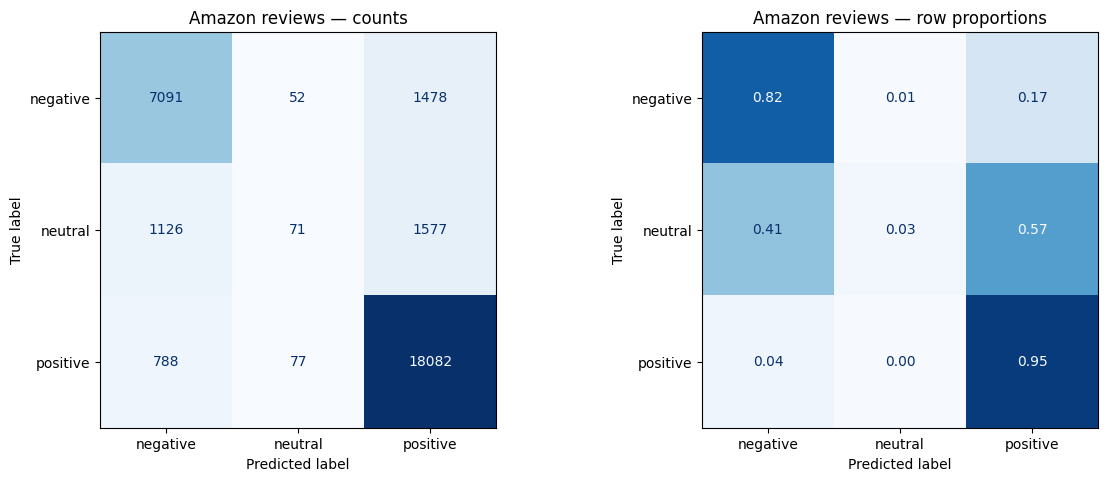

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

amazon_cm = confusion_matrix(y_test, amazon_predictions, labels=LABELS)
amazon_cm_normalized = confusion_matrix(
    y_test, amazon_predictions, labels=LABELS, normalize="true",
)
print("Confusion matrix (rows = actual, columns = predicted):")
print(amazon_cm)
confusion_table = pd.DataFrame(
    amazon_cm, index=pd.Index(LABELS, name="Actual"),
    columns=pd.Index(LABELS, name="Predicted"),
)
display(confusion_table)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.7), constrained_layout=True)
ConfusionMatrixDisplay(amazon_cm, display_labels=LABELS).plot(
    ax=axes[0], cmap="Blues", values_format="d", colorbar=False,
)
ConfusionMatrixDisplay(amazon_cm_normalized, display_labels=LABELS).plot(
    ax=axes[1], cmap="Blues", values_format=".2f", colorbar=False,
    im_kw={"vmin": 0, "vmax": 1},
)
axes[0].set_title("Amazon reviews — counts")
axes[1].set_title("Amazon reviews — row proportions")
plt.show()
assert amazon_cm.sum() == len(y_test)
assert np.array_equal(amazon_cm.sum(axis=1), y_test.value_counts().reindex(LABELS).to_numpy())
assert np.isclose(np.trace(amazon_cm) / amazon_cm.sum(), amazon_scores["Accuracy"])
assert np.allclose(amazon_cm_normalized.sum(axis=1), 1.0)

## Results and Interpretation
The summary below uses the actual held-out results. Star ratings provide proxy sentiment labels, so neutral and mixed reviews can be difficult to separate. The preprocessing and duplicate policy define the population being evaluated; no claim is made about generalization to unseen products or future reviews.

In [19]:
weakest_class = min(LABELS, key=lambda label: amazon_report[label]["f1-score"])
improvement = amazon_scores["Accuracy"] - baseline_scores["Accuracy"]
display(Markdown(
    f"- **Disneyland SVM:** accuracy {disney_accuracy:.2%}, macro-F1 {disney_macro_f1:.4f}.\n"
    f"- **Amazon reviews:** {len(amazon):,} usable; {len(X_train):,} training and {len(X_test):,} testing.\n"
    f"- **Amazon Naive Bayes:** accuracy {amazon_scores['Accuracy']:.2%}, "
    f"macro-F1 {amazon_scores['Macro-F1']:.4f}, balanced accuracy {amazon_scores['Balanced accuracy']:.4f}.\n"
    f"- **Accuracy difference from the majority baseline:** {improvement * 100:+.2f} percentage points.\n"
    f"- **Lowest per-class F1:** {weakest_class}, with precision "
    f"{amazon_report[weakest_class]['precision']:.4f}, recall "
    f"{amazon_report[weakest_class]['recall']:.4f}, and F1 "
    f"{amazon_report[weakest_class]['f1-score']:.4f}.\n"
    "- **Completed:** all six Amazon tasks, the five preprocessing steps, "
    "the printed/visual confusion matrices, and the original Disneyland example."
))

- **Disneyland SVM:** accuracy 84.55%, macro-F1 0.5858.
- **Amazon reviews:** 151,706 usable; 121,364 training and 30,342 testing.
- **Amazon Naive Bayes:** accuracy 83.20%, macro-F1 0.5849, balanced accuracy 0.6008.
- **Accuracy difference from the majority baseline:** +20.75 percentage points.
- **Lowest per-class F1:** neutral, with precision 0.3550, recall 0.0256, and F1 0.0477.
- **Completed:** all six Amazon tasks, the five preprocessing steps, the printed/visual confusion matrices, and the original Disneyland example.

## References
- [Disneyland Reviews dataset](https://www.kaggle.com/datasets/arushchillar/disneyland-reviews), version 1.
- [Amazon Reviews: Unlocked Mobile Phones dataset](https://www.kaggle.com/datasets/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones), version 1.
- [TF-IDF vectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html).
- [Multinomial Naive Bayes](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html).
- [Classification report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html).